# Student Performance Indicator

#### Life Cycle of Machine Learning Project
- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose the Best Model


#### 1) Problem Statement
- This Project understands how the student's performance is affected by other variables such as Gender, Ethnicity, Parental level of Education, Lunch and Test preparation course.

#### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
- The data consists of 8 columns and 1000 rows

#### 2.1) Import Data & Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn & Warnings Libraries.

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

##### Import the CSV Data as Pandas DataFrame

In [11]:
df_stud=pd.read_csv("data/StudPerf.csv")

##### Show Top 5 Records

In [12]:
df_stud.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


##### Shape of the Dataset

In [13]:
df_stud.shape

(1000, 8)

#### 2.2) Dataset Information
- gender: sex of students -> (Male/Female)
- race/ethnicity: ethnicity of students -> (Group A,B,C,D & E)
- parental level of education: parents' final education -> (bachelor's degree, some college, master's degree, associate's degree, high school)
- lunch: having lunch before test (standard or free/reduced)
- test preparation course: complete or not complete before test
- math score
- reading score
- writing score

#### 3) Data Checks to Perform
- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of dataset
- Check various categories present in the different categorical column

#### 3.1 Check Missing Values

In [14]:
df_stud.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Observation: There are no missing values in the dataset.

#### 3.2 Check Duplicates

In [15]:
print(df_stud.duplicated().sum())

0


Observation: There are no duplicate records in the dataset

#### 3.3 Check Data Types

In [16]:
df_stud.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


#### 3.4 Check the number of unique values of each column

In [17]:
df_stud.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

#### 3.5 Check statistics of dataset

In [18]:
df_stud.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From the above description of numerical data, all means are very close to each other - between 66 and 68.05
- All Standard Deviations are also close - between 14.6 and 15.19
- While the minimum score of math is 0, for writing and reading it is much higher (10 and 17)

#### 3.7 Exploring Data

In [22]:
print("Categories in 'gender' Variable: ",end=" ")
print(df_stud['gender'].unique())
print("--------------------------------------------------------------------------")
print("Categories in 'race/ethnicity' Variable: ",end=" ")
print(df_stud['race/ethnicity'].unique())
print("--------------------------------------------------------------------------")
print("Categories in 'parental level of education' Variable: ",end=" ")
print(df_stud['parental level of education'].unique())
print("--------------------------------------------------------------------------")
print("Categories in 'lunch' Variable: ",end=" ")
print(df_stud['lunch'].unique())
print("--------------------------------------------------------------------------")
print("Categories in 'test preparation course' Variable: ",end=" ")
print(df_stud['test preparation course'].unique())

Categories in 'gender' Variable:  <StringArray>
['female', 'male']
Length: 2, dtype: str
--------------------------------------------------------------------------
Categories in 'race/ethnicity' Variable:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
--------------------------------------------------------------------------
Categories in 'parental level of education' Variable:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
--------------------------------------------------------------------------
Categories in 'lunch' Variable:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
--------------------------------------------------------------------------
Categories in 'test preparation course' Variable:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [23]:
# define numerical and categorical columns
numeric_features=[feature for feature in df_stud.columns if df_stud[feature].dtype != 'str']
categorical_features=[feature for feature in df_stud.columns if df_stud[feature].dtype=='str']

print("We have {} numeric_features: {}".format(len(numeric_features),numeric_features))
print("We have {} categorical_features: {}".format(len(categorical_features),categorical_features))

We have 3 numeric_features: ['math score', 'reading score', 'writing score']
We have 5 categorical_features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


#### 3.8 Adding columns for "Total Score" and "Average"

In [24]:
df_stud['total score']=df_stud['math score']+df_stud['reading score']+df_stud['writing score']
df_stud['average']=df_stud['total score']/3
df_stud.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [27]:
reading_full=df_stud[df_stud['reading score']==100]['gender'].count()
writing_full=df_stud[df_stud['writing score']==100]['gender'].count()
math_full=df_stud[df_stud['math score']==100]['gender'].count()

print(f"Number of Students with full marks in Maths: {math_full}")
print(f"Number of Students with full marks in Writing: {writing_full}")
print(f"Number of Students with full marks in Reading: {reading_full}")

Number of Students with full marks in Maths: 7
Number of Students with full marks in Writing: 14
Number of Students with full marks in Reading: 17


In [28]:
reading_less_20=df_stud[df_stud['reading score']<=20]['gender'].count()
writing_less_20=df_stud[df_stud['writing score']<=20]['gender'].count()
math_less_20=df_stud[df_stud['math score']<=20]['gender'].count()

print(f"Number of Students with less than 20 marks in Maths: {math_less_20}")
print(f"Number of Students with less than 20 marks in Writing: {writing_less_20}")
print(f"Number of Students with less than 20 marks in Reading: {reading_less_20}")

Number of Students with less than 20 marks in Maths: 4
Number of Students with less than 20 marks in Writing: 3
Number of Students with less than 20 marks in Reading: 1


##### Insight
- Students have performed the worst in Maths.
- Bes performance is in Reading.

#### 4) Exploring Data (Visualization)

#### 4.1 Visualize Average score distribution to make some conclusion
- histogram
- Kernel Distribution function (KDE)

##### 4.1.1 Histogram & Box Plots

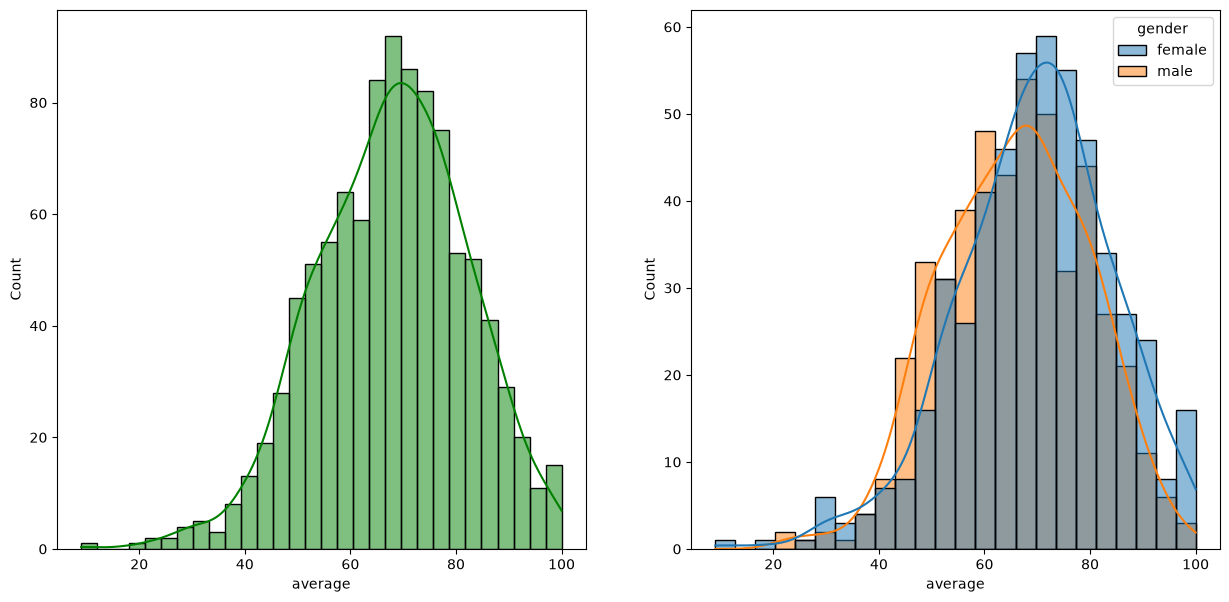

In [29]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df_stud,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df_stud,x='average',kde=True,hue='gender')
plt.show()

##### Insights
- Female Students tend to perform well than Male students.

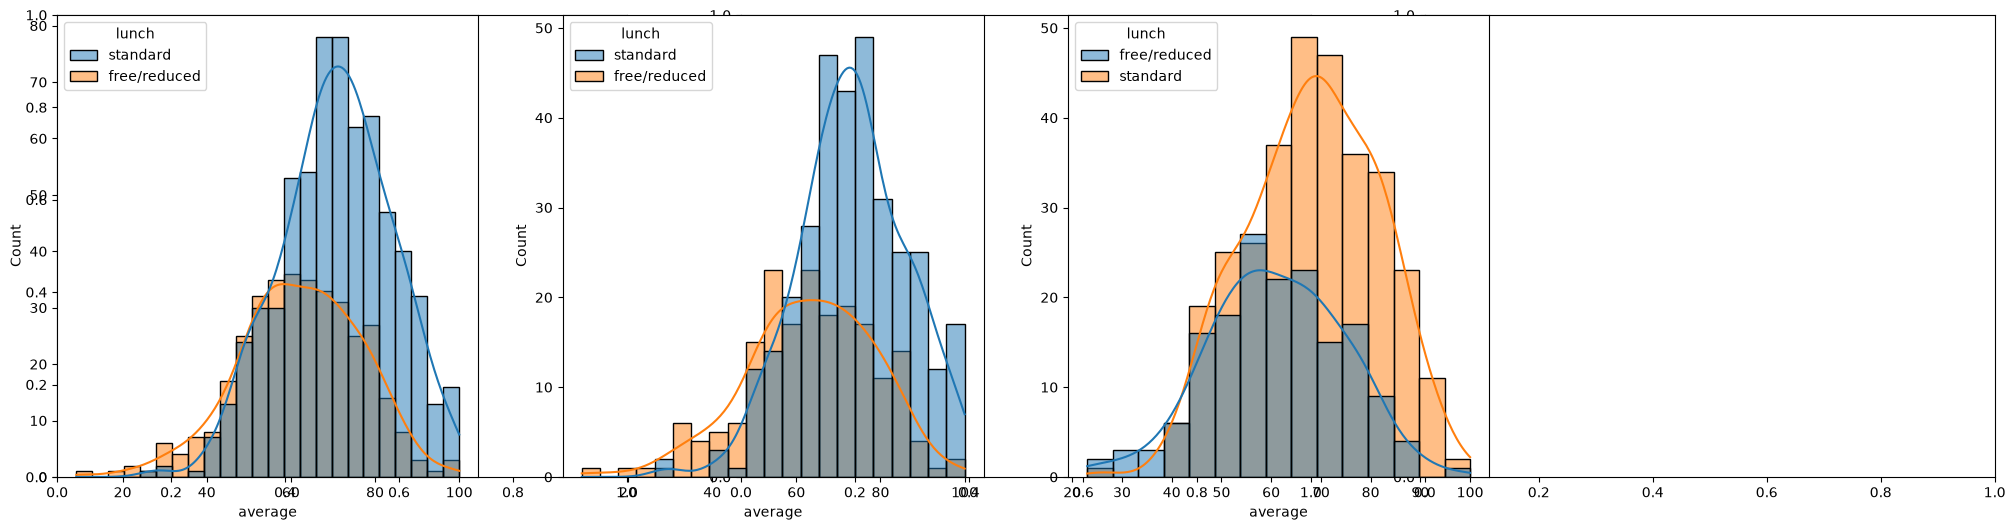

In [33]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df_stud,x='average',hue='lunch',kde=True)
plt.subplot(142)
sns.histplot(data=df_stud[df_stud['gender']=='female'],x='average',hue='lunch',kde=True)
plt.subplot(143)
sns.histplot(data=df_stud[df_stud['gender']=='male'],x='average',kde=True,hue='lunch')
plt.show()

##### Insights
- Standard lunch helps in performing well in exams regardless of gender.

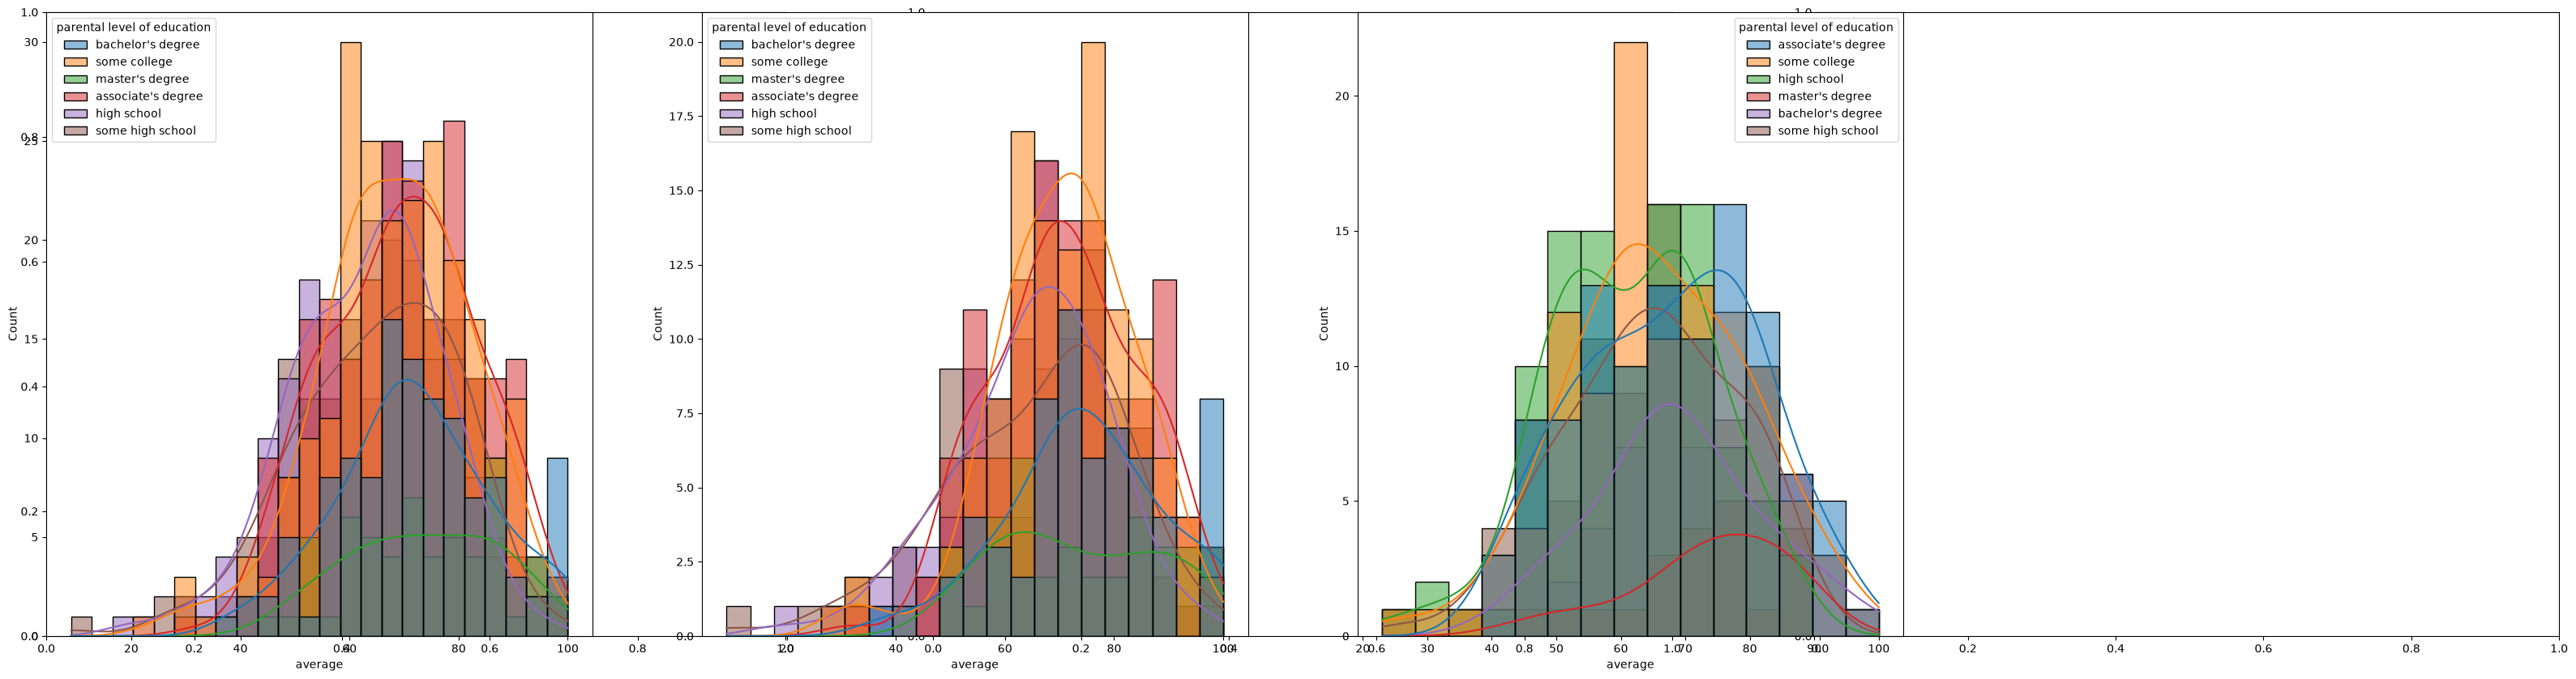

In [41]:
plt.subplots(1,3,figsize=(40,10))
plt.subplot(141)
sns.histplot(data=df_stud,x='average',hue='parental level of education',kde=True)
plt.subplot(142)
sns.histplot(data=df_stud[df_stud['gender']=='female'],x='average',hue='parental level of education',kde=True)
plt.subplot(143)
sns.histplot(data=df_stud[df_stud['gender']=='male'],x='average',hue='parental level of education',kde=True)
plt.show()

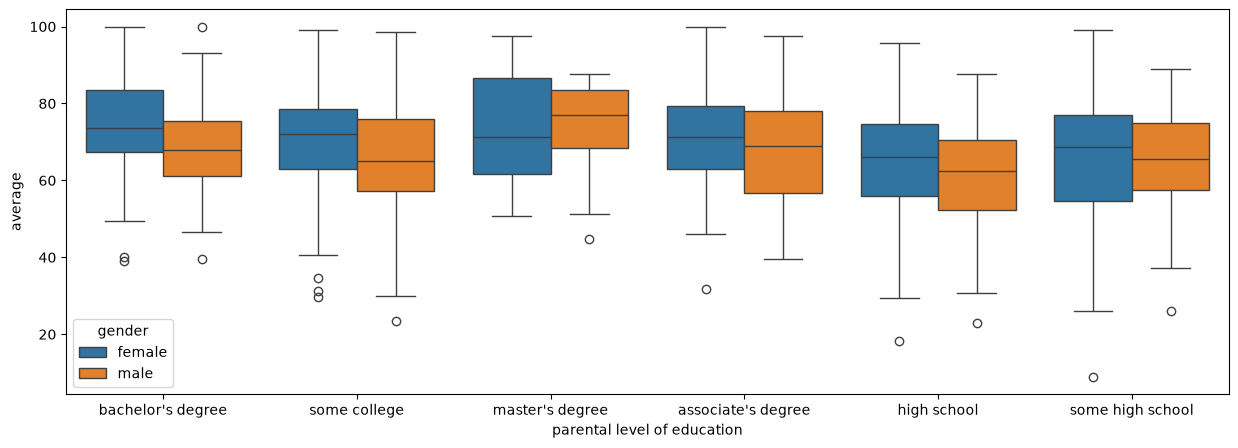

In [46]:
plt.figure(figsize=(15,5))
sns.boxplot(
    data=df_stud,
    x='parental level of education',
    y='average',
    hue='gender'
)
plt.show()

##### Insights
- Students whose parents have a master's degree tend to have relatively high average exam scores, particularly among male students.
- Female students whose parents have some college education show a relatively high median average score.
- Female students have a higher median average score than males in most parental-education categories, with the master's-degree category being a notable exception.


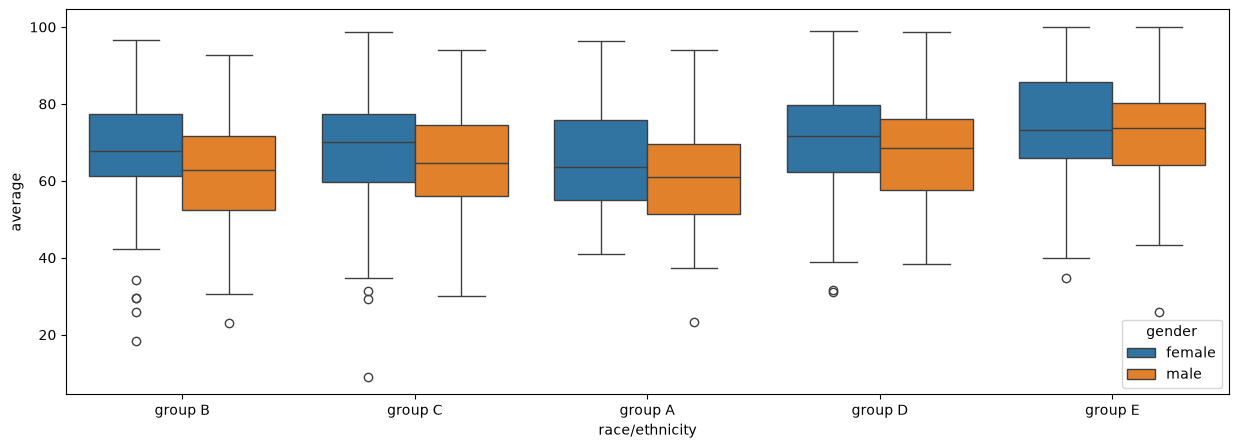

In [48]:
plt.figure(figsize=(15,5))
sns.boxplot(
    data=df_stud,
    x='race/ethnicity',
    y='average',
    hue='gender'
    
)
plt.show()

##### Insights
- There is somewhat variations in average scores of Students from different Ethnicity.
- Students from ethnicity group E have relative higher median score than other ethnic groups.
- In all Ethnic groups, female students tend to perform slightly well than male students.

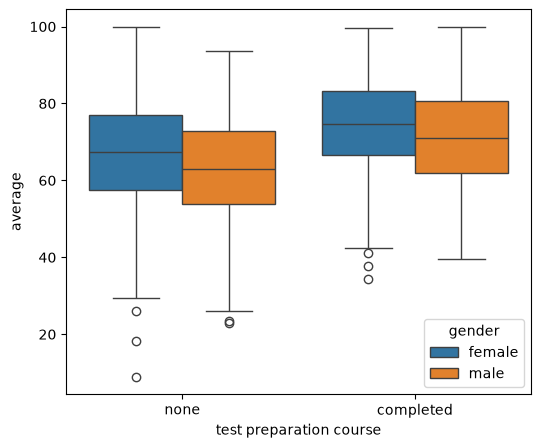

In [52]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x='test preparation course',
    y='average',
    data=df_stud,
    hue='gender'
)
plt.show()


##### Insights
- Students who have completed test preparation course tend to perform relatively well with higher median scores than those students who haven't taken the course.

#### 4.2 Maximum Score of Students in All 3 Subjects

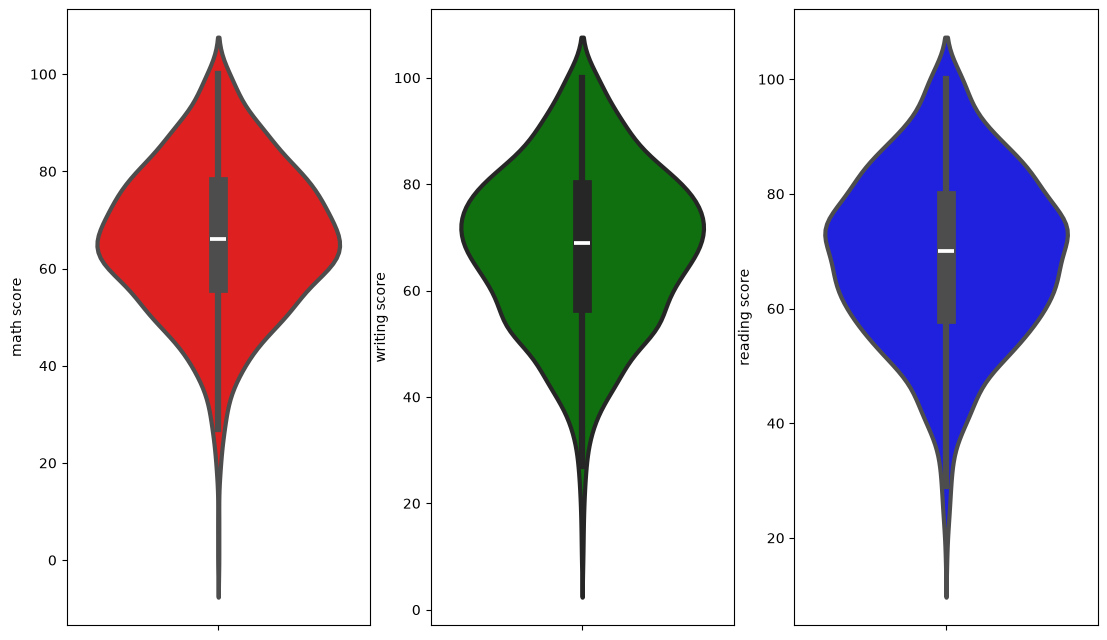

In [49]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
sns.violinplot(y='math score',data=df_stud,color='red',linewidth=3)
plt.subplot(1,4,2)
sns.violinplot(y='writing score',data=df_stud,color='green',linewidth=3)
plt.subplot(1,4,3)
sns.violinplot(y='reading score',data=df_stud,color='blue',linewidth=3)
plt.show()

##### Insights
- Students have relatively higher median score in Reading, followed by writing then Maths.
- Reading has the highest amount of students with maximum score and Maths has the least.

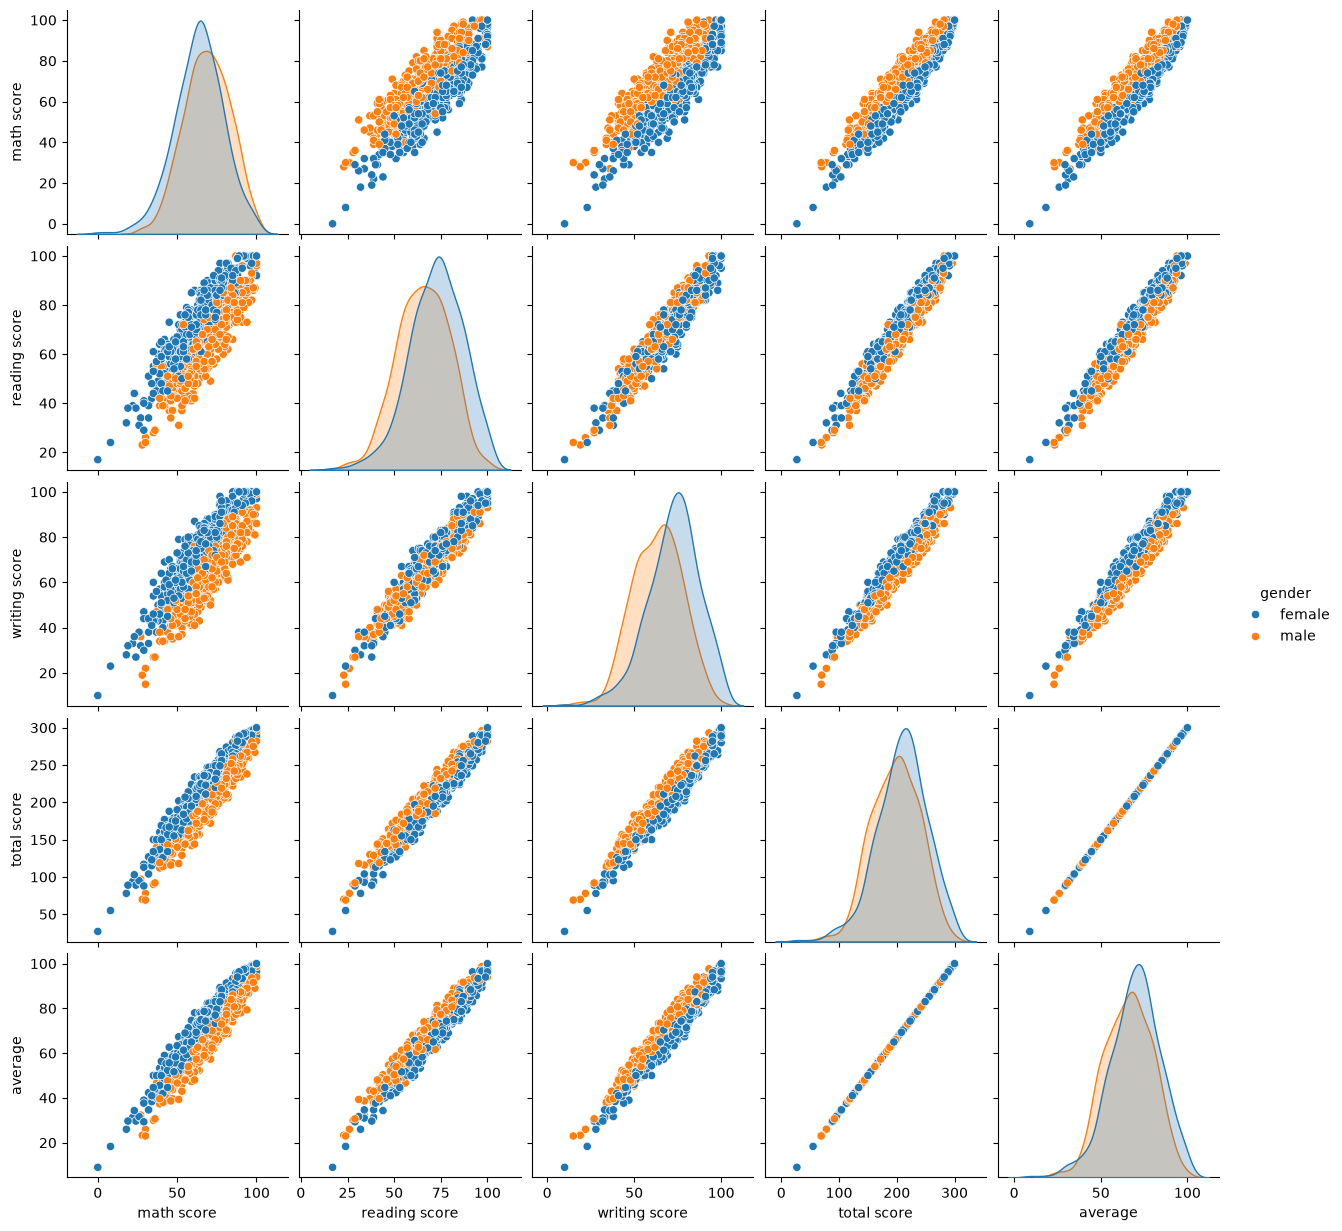

In [53]:
sns.pairplot(df_stud,hue = 'gender')
plt.show()

# Conclusion

The exploratory data analysis of the Student Performance dataset revealed several patterns in students' academic performance. The dataset contains 1,000 observations and 8 original features, with no missing values or duplicate records.

Among the three subjects, students generally performed best in **Reading**, followed by **Writing**, while **Mathematics** had the lowest overall performance. Female students tended to have higher average and median scores than male students across most groups.

Students with **standard lunch** generally showed higher average scores compared with students receiving free/reduced lunch. Similarly, students who **completed the test preparation course** tended to achieve higher median scores than those who did not complete it.

Some variation in performance was also observed across **parental education levels and ethnicity groups**. Students whose parents had a master's degree showed relatively high average scores, particularly among male students, while students from ethnicity Group E had a relatively higher median score. However, the score distributions across parental education and ethnicity groups overlap considerably.

Overall, the analysis suggests that **gender, lunch type, test preparation, parental education, and ethnicity are associated with differences in student performance**, while Reading appears to be the strongest-performing subject and Mathematics the weakest. These findings represent patterns and associations observed in the dataset and should not be interpreted as evidence that any individual factor directly causes better or worse academic performance.
